# Notebook 02 — Analyse exploratoire des données
## Projet : Aide à la commercialisation foncière — WISDOM International

Objectif : explorer la base de 408 parcelles pour identifier les
caractéristiques qui distinguent les parcelles vendues des parcelles
disponibles, et préparer la modélisation.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style visuel des graphiques
sns.set_theme(style="whitegrid")

# On charge la base PROPRE produite en Phase 1
base = pd.read_csv("../02_donnees_propres/base_parcelles.csv")

print("Dimensions :", base.shape)
base.head()

Dimensions : (408, 8)


,TF,bloc,lot,superficie,restante,client,statut,vendu
0,5880,4.0,9.0,500.0,0.0,KAMTE EMMA,Vendu,1
1,5880,4.0,10.0,500.0,0.0,TCHUIMBOU SIKAZI SERGES PATRICK,Vendu,1
2,5880,4.0,11.0,500.0,500.0,ONGUENE CLAUDE BERTRAND JUNIOR,Disponible,0
3,5880,4.0,12.0,500.0,0.0,TCHUIMBOU SIKAZI SERGES PATRICK,Vendu,1
4,5880,4.0,13.0,500.0,500.0,NYOM ANDRE RENE,Disponible,0


In [6]:
# 1) Types de chaque colonne + valeurs manquantes
print("=== Informations générales ===")
base.info()

print("\n=== Valeurs manquantes par colonne ===")
print(base.isna().sum())

# 2) Statistiques de la superficie (la seule vraie variable numérique continue)
print("\n=== Statistiques de la superficie (m²) ===")
print(base["superficie"].describe())

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TF          408 non-null    object 
 1   bloc        408 non-null    float64
 2   lot         408 non-null    float64
 3   superficie  408 non-null    float64
 4   restante    405 non-null    float64
 5   client      291 non-null    object 
 6   statut      408 non-null    object 
 7   vendu       408 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 25.6+ KB

=== Valeurs manquantes par colonne ===
TF              0
bloc            0
lot             0
superficie      0
restante        3
client        117
statut          0
vendu           0
dtype: int64

=== Statistiques de la superficie (m²) ===
count     408.000000
mean      445.639706
std       155.213426
min        11.000000
25%       386.500000
50%       500.000000
75%       500.000000
max 

In [7]:
# On affiche les lignes où "restante" est vide
base[base["restante"].isna()]

,TF,bloc,lot,superficie,restante,client,statut,vendu
388,3989,8.0,1.0,388.0,NaN,NaN,Disponible,0
389,3989,8.0,2.0,112.0,NaN,NaN,Disponible,0
391,3989,8.0,4.0,500.0,NaN,NaN,Disponible,0


statut
Vendu         358
Disponible     50
Name: count, dtype: int64


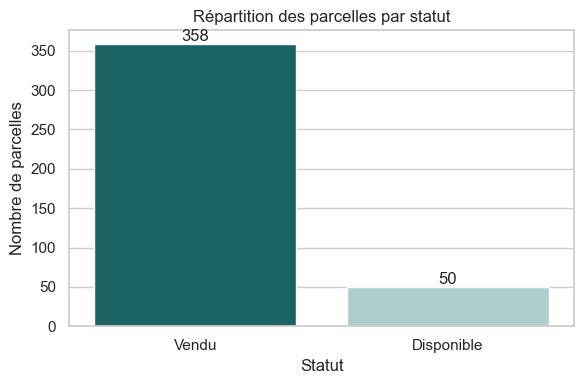

In [8]:
# Comptage des deux catégories
compte = base["statut"].value_counts()
print(compte)

# Graphique en barres
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=base, x="statut", hue="statut",
                   palette=["#0F6E6E", "#A9D2D2"], legend=False)
ax.set_title("Répartition des parcelles par statut")
ax.set_xlabel("Statut")
ax.set_ylabel("Nombre de parcelles")

# Afficher le nombre au-dessus de chaque barre
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

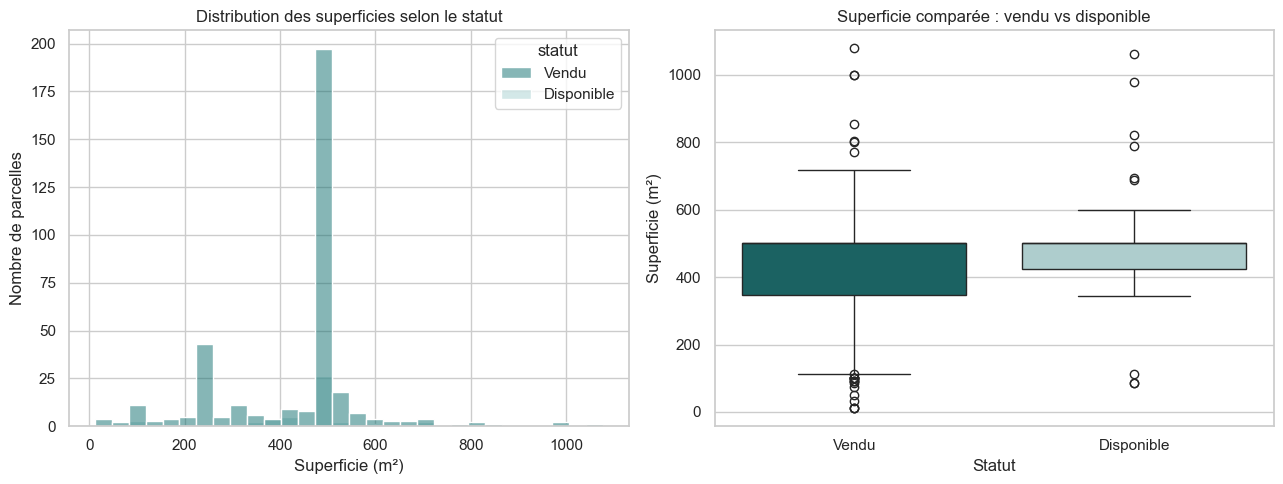

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : distribution des superficies selon le statut
sns.histplot(data=base, x="superficie", hue="statut", bins=30,
             palette=["#0F6E6E", "#A9D2D2"], ax=ax[0])
ax[0].set_title("Distribution des superficies selon le statut")
ax[0].set_xlabel("Superficie (m²)")
ax[0].set_ylabel("Nombre de parcelles")

# Graphique 2 : boîtes à moustaches (comparaison des deux groupes)
sns.boxplot(data=base, x="statut", y="superficie", hue="statut",
            palette=["#0F6E6E", "#A9D2D2"], legend=False, ax=ax[1])
ax[1].set_title("Superficie comparée : vendu vs disponible")
ax[1].set_xlabel("Statut")
ax[1].set_ylabel("Superficie (m²)")

plt.tight_layout()
plt.show()

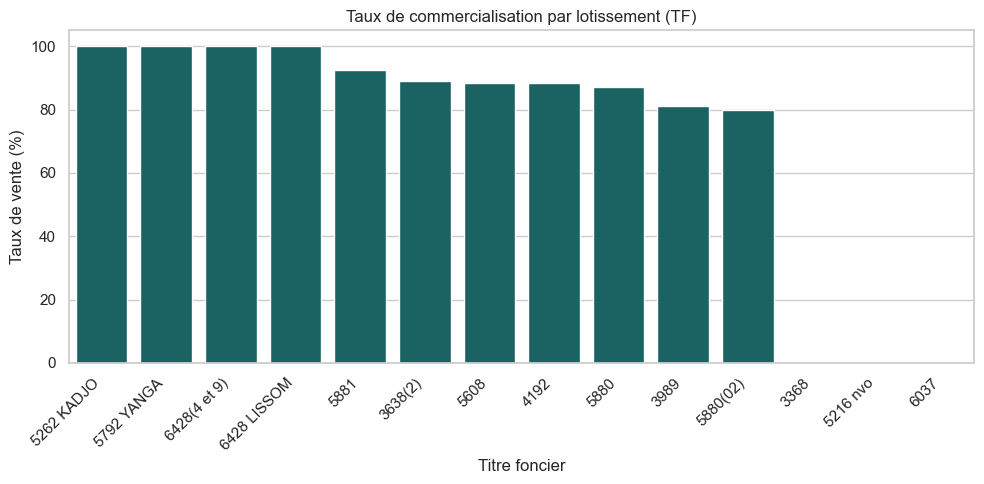

TF
5262 KADJO      100.0
5792 YANGA      100.0
6428(4 et 9)    100.0
6428 LISSOM     100.0
5881             92.6
3638(2)          88.9
5608             88.5
4192             88.5
5880             87.3
3989             81.2
5880(02)         80.0
3368              0.0
5216 nvo          0.0
6037              0.0
Name: vendu, dtype: float64


In [10]:
# Taux de vente moyen par lotissement (TF), trié
taux_tf = base.groupby("TF")["vendu"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=taux_tf.index, y=taux_tf.values, color="#0F6E6E")
ax.set_title("Taux de commercialisation par lotissement (TF)")
ax.set_xlabel("Titre foncier")
ax.set_ylabel("Taux de vente (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(taux_tf.round(1))

      taux_vente  nb_parcelles
bloc                          
5.0        100.0            11
21.0       100.0             8
12.0       100.0            15
14.0       100.0            13
9.0        100.0            16
7.0        100.0            18
16.0       100.0            14
29.0       100.0            14
15.0       100.0            30
6.0         97.6            41
22.0        92.9            14
11.0        90.9            33
8.0         89.8            49
20.0        87.5             8
13.0        86.2            29
2.0         80.0            10
4.0         76.9            13
10.0        69.2            13
3.0         66.7            27
1.0         50.0            12
19.0        33.3             6
30.0        16.7             6


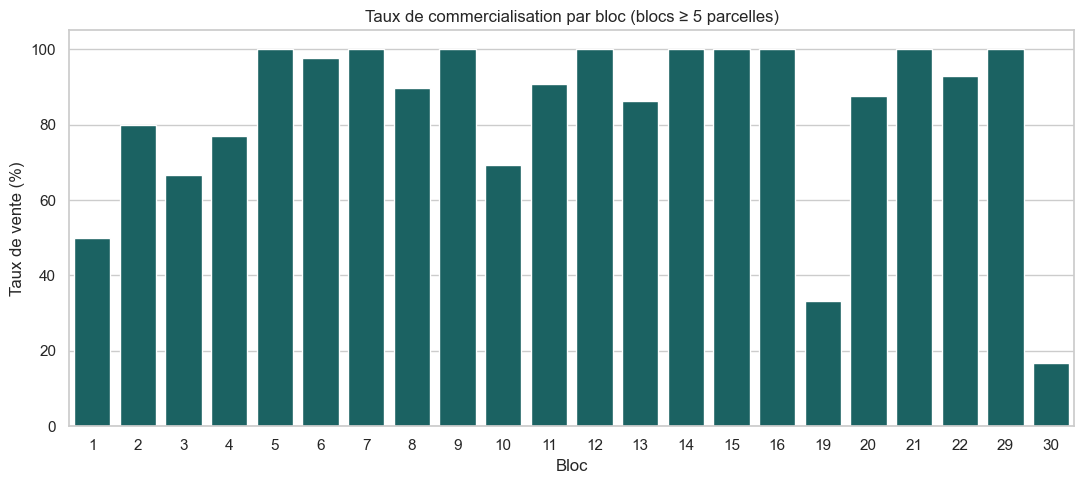

In [11]:
# Taux de vente ET nombre de parcelles par bloc
analyse_bloc = base.groupby("bloc").agg(
    taux_vente=("vendu", "mean"),
    nb_parcelles=("vendu", "count")
)
analyse_bloc["taux_vente"] = (analyse_bloc["taux_vente"] * 100).round(1)

# On ne garde que les blocs ayant au moins 5 parcelles (taux plus fiable)
blocs_fiables = analyse_bloc[analyse_bloc["nb_parcelles"] >= 5].sort_values("taux_vente", ascending=False)

print(blocs_fiables)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=blocs_fiables.index.astype(int), y=blocs_fiables["taux_vente"], color="#0F6E6E")
ax.set_title("Taux de commercialisation par bloc (blocs ≥ 5 parcelles)")
ax.set_xlabel("Bloc")
ax.set_ylabel("Taux de vente (%)")
plt.tight_layout()
plt.show()

## Synthèse de l'analyse exploratoire

- **Variable cible déséquilibrée** : 358 parcelles vendues (~88 %) contre 50 disponibles (~12 %).
- **Superficie** : faiblement discriminante — vendues et disponibles ont des tailles proches (~500 m²).
- **Lotissement (TF)** : taux de vente contrastés (de 0 % à 100 %).
- **Bloc** : très discriminant sur des effectifs fiables (de 16,7 % à 100 %).

**Conclusion** : la localisation (bloc, lotissement) est le principal facteur prédictif,
la superficie joue un rôle secondaire. Le modèle s'appuiera donc sur ces variables, avec
une vigilance particulière sur le risque de sur-apprentissage lié au bloc (à contrôler
par validation croisée et test sans la variable bloc).